
# Ireland Employment Permits 2025 — Exploratory Analysis

Ireland's employment permit system lets non-EEA nationals take up jobs the
domestic/EEA labour market can't fill. The Department of Enterprise, Trade &
Employment (DETE) publishes permit statistics broken out by **nationality**,
**county**, **economic sector**, and **sponsoring company**.

This notebook combines all four breakdowns for **2025** (31,044 permits
issued, 3,432 refused) to answer:

1. Who is coming, and from where?
2. Where in Ireland are they working?
3. Which sectors and companies rely most on the scheme?
4. How concentrated is that reliance — a handful of employers, or thousands?

**Data source:** DETE Employment Permits Statistics, 2025 (`data/raw/*.xlsx`).
**Reproduce:** `python src/clean_data.py` regenerates everything in `data/processed/`.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

DATA = Path("..") / "data" / "processed"

# --- house style -----------------------------------------------------------
INK      = "#1B2A38"   # near-navy, primary bars / text
SLATE    = "#5B7083"   # secondary bars
ACCENT   = "#D9843A"   # single warm accent for "the point" of a chart
GRID     = "#E4E7EA"
BG       = "#FFFFFF"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "axes.edgecolor": GRID,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.labelsize": 10.5,
    "text.color": INK,
    "axes.labelcolor": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "ytick.left": False,
    "xtick.bottom": False,
})

def commas(ax, axis="x"):
    fmt = mticker.FuncFormatter(lambda v, _: f"{int(v):,}")
    (ax.xaxis if axis == "x" else ax.yaxis).set_major_formatter(fmt)

print("Style configured.")


Style configured.


## 1. Load the cleaned data

In [2]:

nationality = pd.read_csv(DATA / "permits_by_nationality.csv")
county      = pd.read_csv(DATA / "permits_by_county.csv")
sector_wide = pd.read_csv(DATA / "permits_by_sector_wide.csv")
sector_long = pd.read_csv(DATA / "permits_by_sector_monthly.csv")
comp_wide   = pd.read_csv(DATA / "permits_by_company_wide.csv")
comp_long   = pd.read_csv(DATA / "permits_by_company_monthly.csv")

MONTHS = ["January","February","March","April","May","June",
          "July","August","September","October","November","December"]
sector_long["month"] = pd.Categorical(sector_long["month"], MONTHS, ordered=True)
comp_long["month"]   = pd.Categorical(comp_long["month"], MONTHS, ordered=True)

print(f"{'nationality':<12} {nationality.shape}   ({nationality['issued'].sum():,} issued)")
print(f"{'county':<12} {county.shape}   ({county['issued'].sum():,} issued)")
print(f"{'sector':<12} {sector_wide.shape}   ({sector_wide['total_issued'].sum():,} issued)")
print(f"{'company':<12} {comp_wide.shape}   ({comp_wide['total_issued'].sum():,} issued)")


nationality  (136, 5)   (31,044 issued)
county       (27, 5)   (31,044 issued)
sector       (26, 16)   (31,044 issued)
company      (8330, 14)   (31,044 issued)


## 2. National overview

In [3]:

total_issued  = nationality["issued"].sum()
total_refused = nationality["refused"].sum()
total_apps    = total_issued + total_refused
overall_rate  = total_refused / total_apps

monthly = sector_long.groupby("month", observed=True)["issued"].sum()

print(f"Applications decided in 2025 : {total_apps:,}")
print(f"Permits issued               : {total_issued:,}")
print(f"Permits refused               : {total_refused:,}")
print(f"Overall refusal rate          : {overall_rate:.1%}")
print(f"Countries of origin represented: {(nationality['issued']>0).sum()}")
print(f"Sponsoring companies           : {(comp_wide['total_issued']>0).sum():,}")
print()
print("Busiest month :", monthly.idxmax(), f"({monthly.max():,} issued)")
print("Quietest month:", monthly.idxmin(), f"({monthly.min():,} issued)")


Applications decided in 2025 : 34,476
Permits issued               : 31,044
Permits refused               : 3,432
Overall refusal rate          : 10.0%
Countries of origin represented: 132
Sponsoring companies           : 8,330

Busiest month : January (3,798 issued)
Quietest month: April (1,668 issued)


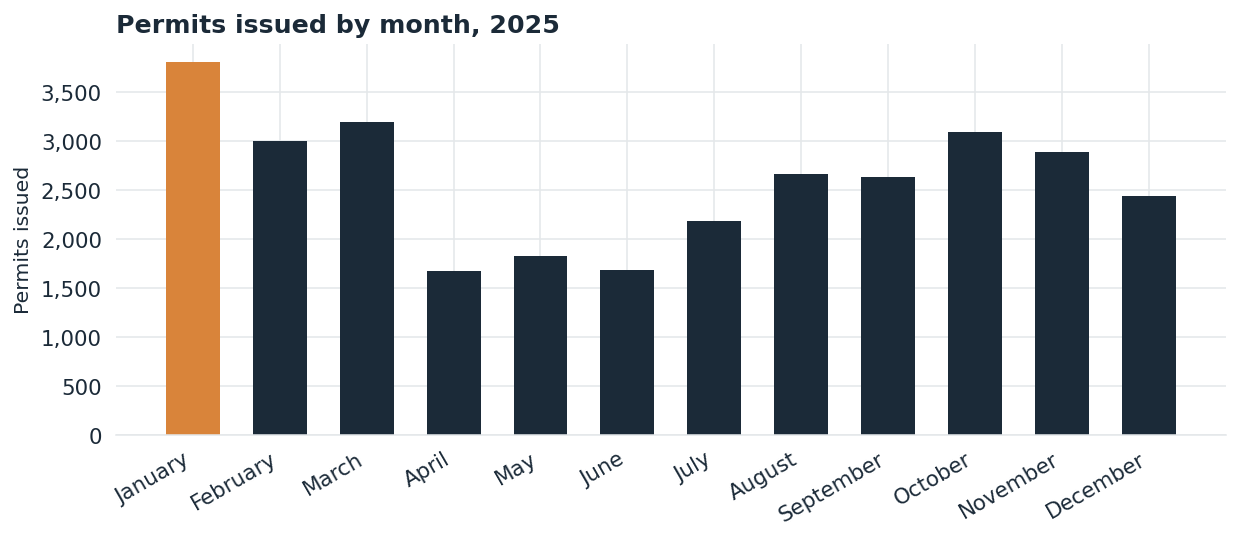

In [4]:

fig, ax = plt.subplots(figsize=(9, 4))
colors = [ACCENT if m == monthly.idxmax() else INK for m in monthly.index]
ax.bar(monthly.index, monthly.values, color=colors, width=0.62)
ax.set_title("Permits issued by month, 2025")
ax.set_ylabel("Permits issued")
commas(ax, "y")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()



**January is the single busiest month** (3,798 permits), with April and June
the quietest. Volume rebuilds steadily from the spring trough into a second,
smaller peak in October — a pattern worth reading alongside the sector
breakdown below, where Health & Social Work drives a large share of the
overall total.


## 3. Who is coming, and from where? — Nationality

India alone accounts for 32.0% of all permits issued.
The top 3 nationalities (India, Philippines, Brazil) account for 53.9%.


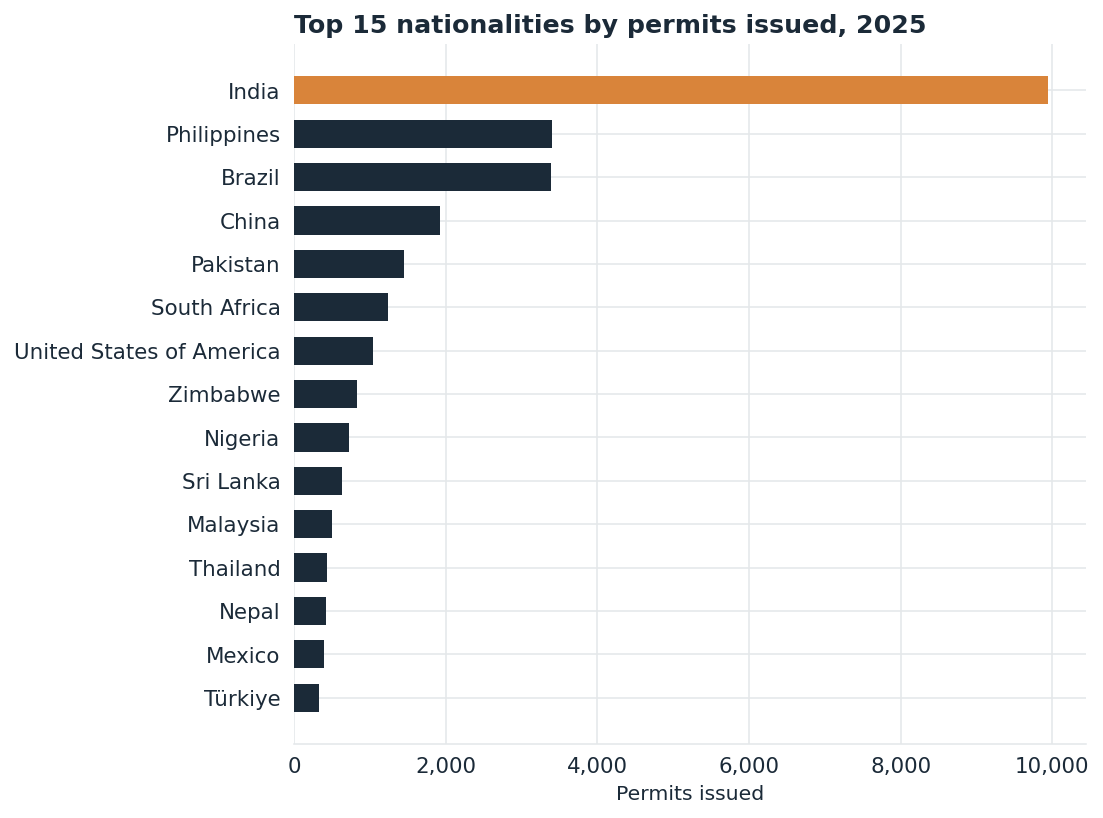

In [5]:

top_n = nationality.head(15).sort_values("issued")

fig, ax = plt.subplots(figsize=(8, 6))
colors = [ACCENT if i == len(top_n) - 1 else INK for i in range(len(top_n))]
ax.barh(top_n["nationality"], top_n["issued"], color=colors, height=0.65)
ax.set_title("Top 15 nationalities by permits issued, 2025")
ax.set_xlabel("Permits issued")
commas(ax, "x")
plt.tight_layout()
plt.show()

india_share = nationality.loc[nationality["nationality"] == "India", "issued"].iloc[0] / total_issued
top3_share  = nationality.head(3)["issued"].sum() / total_issued
print(f"India alone accounts for {india_share:.1%} of all permits issued.")
print(f"The top 3 nationalities (India, Philippines, Brazil) account for {top3_share:.1%}.")



India dominates by a wide margin — roughly a third of every permit issued
nationwide, more than the next five countries combined. The Philippines and
Brazil (both with a strong healthcare and hospitality presence in Ireland)
round out the top three.


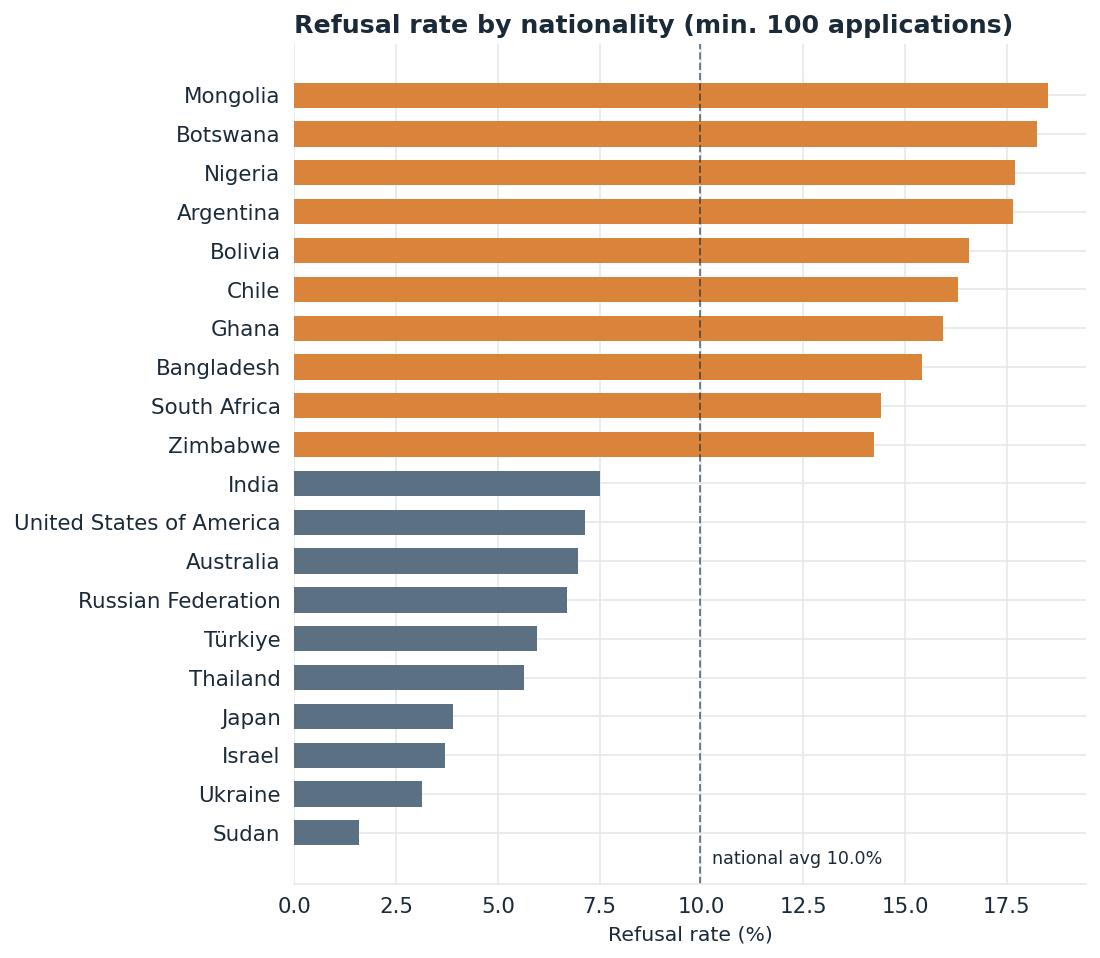

In [6]:

sizable = nationality[nationality["applications"] >= 100].copy()
sizable = sizable.sort_values("refusal_rate", ascending=False)
highest = sizable.head(10).sort_values("refusal_rate")
lowest  = sizable.tail(10).sort_values("refusal_rate")
combined = pd.concat([lowest, highest]).drop_duplicates(subset="nationality")

fig, ax = plt.subplots(figsize=(8, 7))
plot_df = pd.concat([lowest, highest]).sort_values("refusal_rate")
colors = [ACCENT if r >= sizable["refusal_rate"].median() else SLATE for r in plot_df["refusal_rate"]]
ax.barh(plot_df["nationality"], plot_df["refusal_rate"] * 100, color=colors, height=0.65)
ax.set_title("Refusal rate by nationality (min. 100 applications)")
ax.set_xlabel("Refusal rate (%)")
ax.axvline(overall_rate * 100, color=INK, linestyle="--", linewidth=1, alpha=0.6)
ax.text(overall_rate * 100 + 0.3, -0.8, f"national avg {overall_rate:.1%}", fontsize=9, color=INK)
plt.tight_layout()
plt.show()



Refusal rates for higher-volume nationalities cluster fairly tightly around
the **10.0% national average** — there's no nationality with an extreme
outlier rate once volume is filtered to at least 100 applications. Sudan and
Ukraine sit lowest; Mongolia and Botswana highest, though all remain within
roughly a 4-to-19% band.


## 4. Where in Ireland? — County

Dublin accounts for 47.1% of all permits issued.
Top 5 outside Dublin:
  county  issued
    Cork    2973
Limerick    1543
   Meath    1252
 Kildare    1194
  Galway    1104


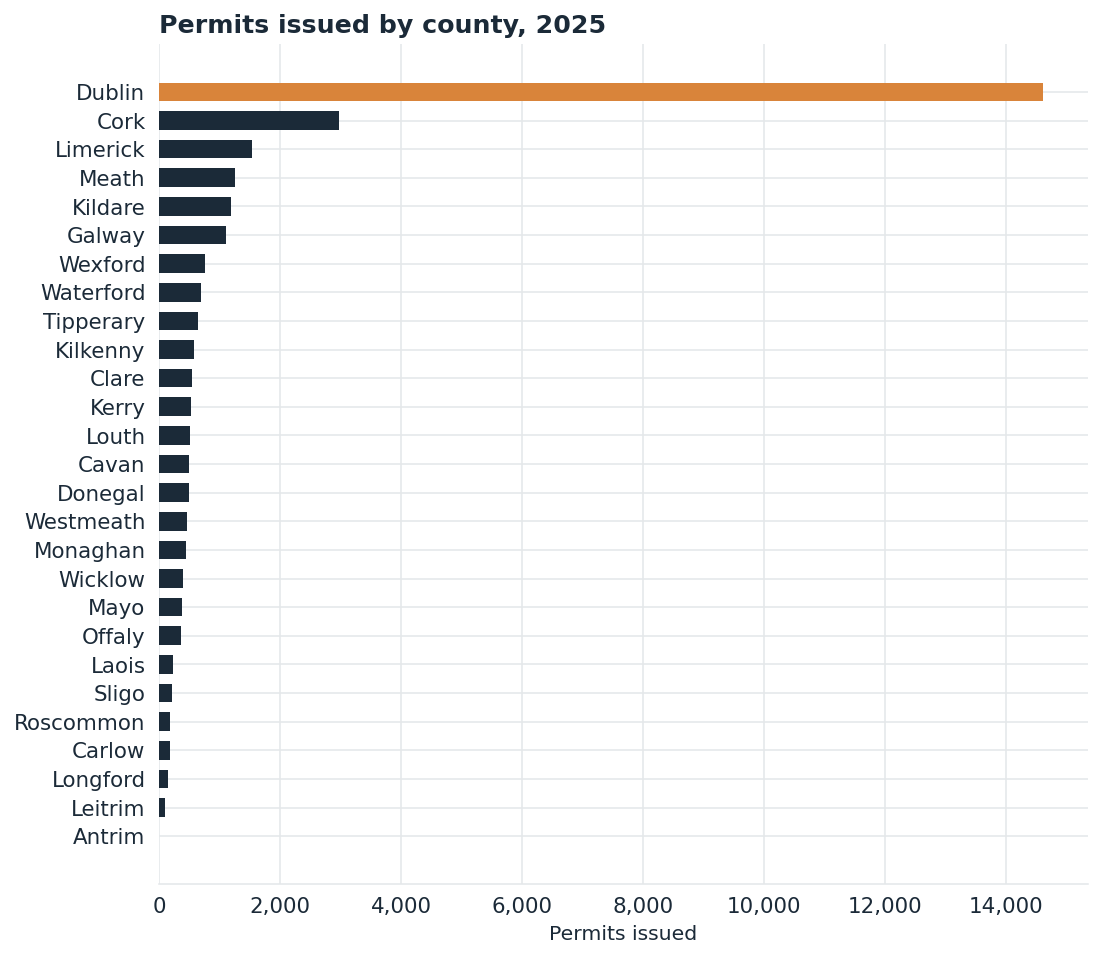

In [7]:

top_counties = county.sort_values("issued", ascending=False)
dublin_share = county.loc[county["county"] == "Dublin", "issued"].iloc[0] / total_issued

fig, ax = plt.subplots(figsize=(8, 7))
plot_df = top_counties.sort_values("issued")
colors = [ACCENT if c == "Dublin" else INK for c in plot_df["county"]]
ax.barh(plot_df["county"], plot_df["issued"], color=colors, height=0.65)
ax.set_title("Permits issued by county, 2025")
ax.set_xlabel("Permits issued")
commas(ax, "x")
plt.tight_layout()
plt.show()

print(f"Dublin accounts for {dublin_share:.1%} of all permits issued.")
print("Top 5 outside Dublin:")
print(top_counties[top_counties["county"] != "Dublin"].head(5)[["county","issued"]].to_string(index=False))



Dublin alone absorbs nearly **half of all permits nationwide** — no
surprise given its concentration of tech, pharma and hospital-group
employers. Cork, Limerick, Meath and Kildare form a clear second tier, each
still under 10% of Dublin's total.


## 5. Which sectors rely on the scheme?

Health & Social Work Activities alone: 25.6% of all permits.


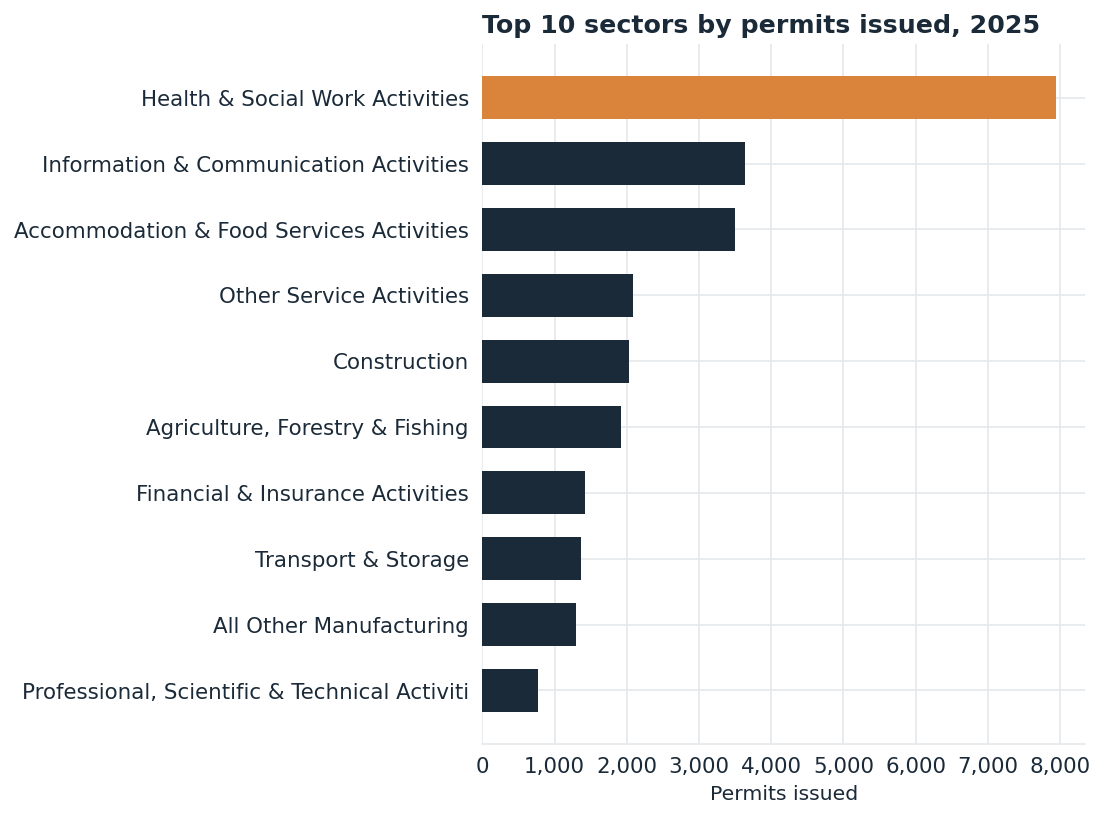

In [8]:

top_sectors = sector_wide.head(10).sort_values("total_issued")

fig, ax = plt.subplots(figsize=(8, 6))
colors = [ACCENT if i == len(top_sectors) - 1 else INK for i in range(len(top_sectors))]
labels = top_sectors["sector_label"].str.slice(0, 45)
ax.barh(labels, top_sectors["total_issued"], color=colors, height=0.65)
ax.set_title("Top 10 sectors by permits issued, 2025")
ax.set_xlabel("Permits issued")
commas(ax, "x")
plt.tight_layout()
plt.show()

health_share = sector_wide.loc[sector_wide["sector_label"] == "Health & Social Work Activities", "total_issued"].iloc[0] / total_issued
print(f"Health & Social Work Activities alone: {health_share:.1%} of all permits.")


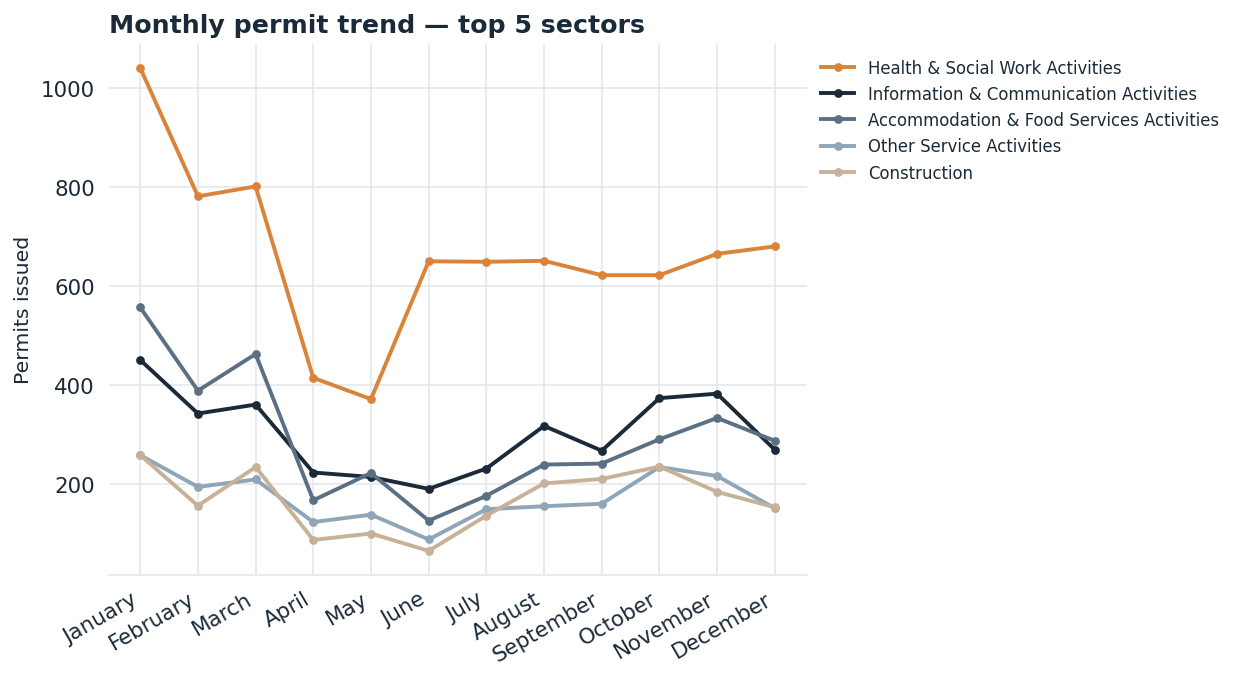

In [9]:

top5_codes = sector_wide.head(5)["sector"].tolist()
trend = (sector_long[sector_long["sector"].isin(top5_codes)]
         .pivot_table(index="month", columns="sector", values="issued", observed=True)
         .reindex(MONTHS)[top5_codes])

fig, ax = plt.subplots(figsize=(9, 5))
palette = [ACCENT, INK, SLATE, "#8FA6B8", "#C7B299"]
for col, c in zip(trend.columns, palette):
    label = col.split(" - ", 1)[-1]
    ax.plot(trend.index, trend[col], marker="o", markersize=3.5, linewidth=2, color=c, label=label)
ax.set_title("Monthly permit trend — top 5 sectors")
ax.set_ylabel("Permits issued")
plt.xticks(rotation=30, ha="right")
ax.legend(fontsize=8.5, frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()



**Health & Social Work Activities is in a league of its own** — a quarter of
all permits issued nationally, and the largest single monthly total in every
month of the year. It spikes sharply in January (likely new-year hospital
and nursing-home rostering), dips over the spring, then settles into a
stable, elevated plateau from July through December. Information &
Communication (tech) and Accommodation & Food Services form a clear second
tier, both trending upward into Q4.


## 6. Company-level concentration

8,330 distinct companies sponsored at least one permit in 2025.
The single largest sponsor is Google Ireland Limited (368 permits, 1.2% of the national total).
The top 20 companies alone (0.2% of sponsors) account for 10.6% of all permits issued.
4,742 companies (57% of all sponsors) issued exactly one permit all year.


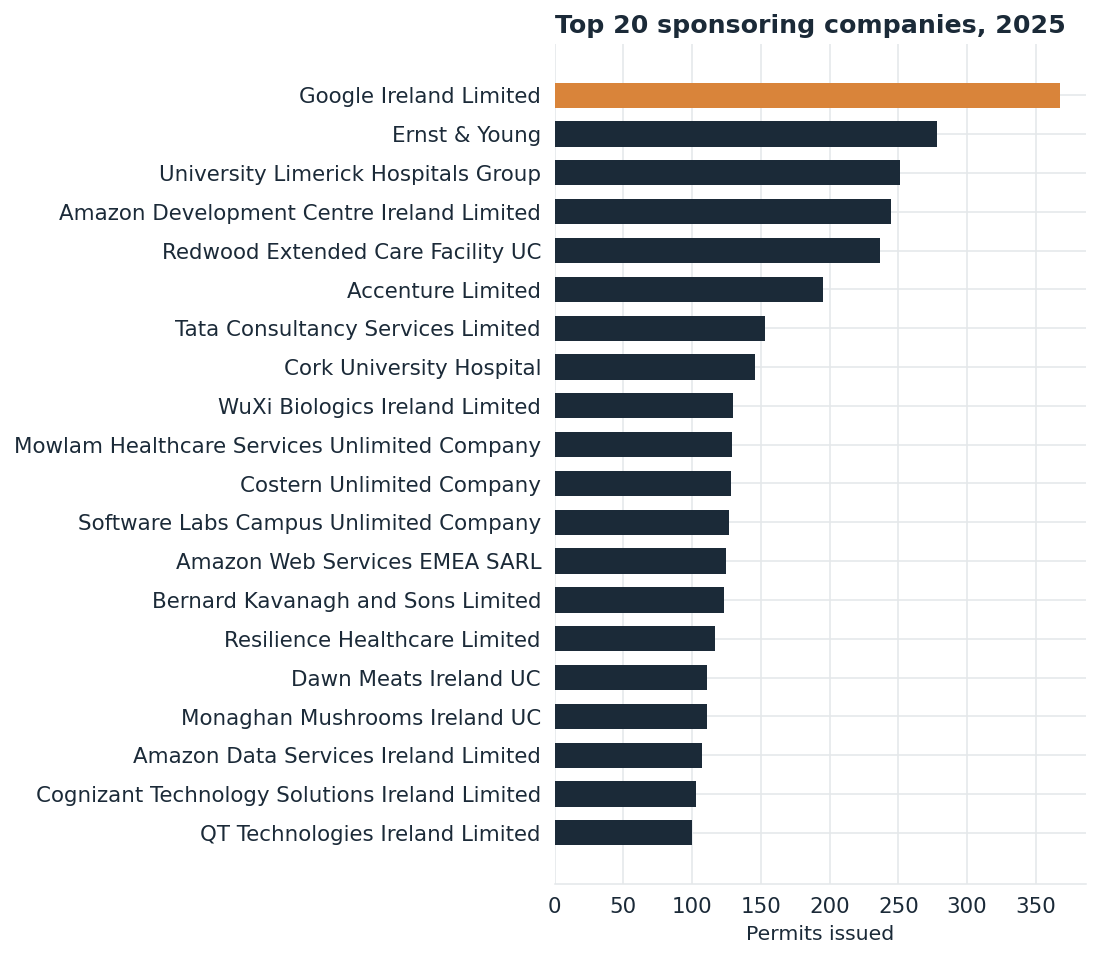

In [10]:

top20 = comp_wide.head(20).sort_values("total_issued")

fig, ax = plt.subplots(figsize=(8, 7))
colors = [ACCENT if i == len(top20) - 1 else INK for i in range(len(top20))]
ax.barh(top20["company"], top20["total_issued"], color=colors, height=0.65)
ax.set_title("Top 20 sponsoring companies, 2025")
ax.set_xlabel("Permits issued")
commas(ax, "x")
plt.tight_layout()
plt.show()

n_companies = len(comp_wide)
top20_share = comp_wide.head(20)["total_issued"].sum() / total_issued
single_permit_firms = (comp_wide["total_issued"] == 1).sum()
print(f"{n_companies:,} distinct companies sponsored at least one permit in 2025.")
print(f"The single largest sponsor is {comp_wide.iloc[0]['company']} ({comp_wide.iloc[0]['total_issued']:.0f} permits, {comp_wide.iloc[0]['total_issued']/total_issued:.1%} of the national total).")
print(f"The top 20 companies alone (0.2% of sponsors) account for {top20_share:.1%} of all permits issued.")
print(f"{single_permit_firms:,} companies ({single_permit_firms/n_companies:.0%} of all sponsors) issued exactly one permit all year.")


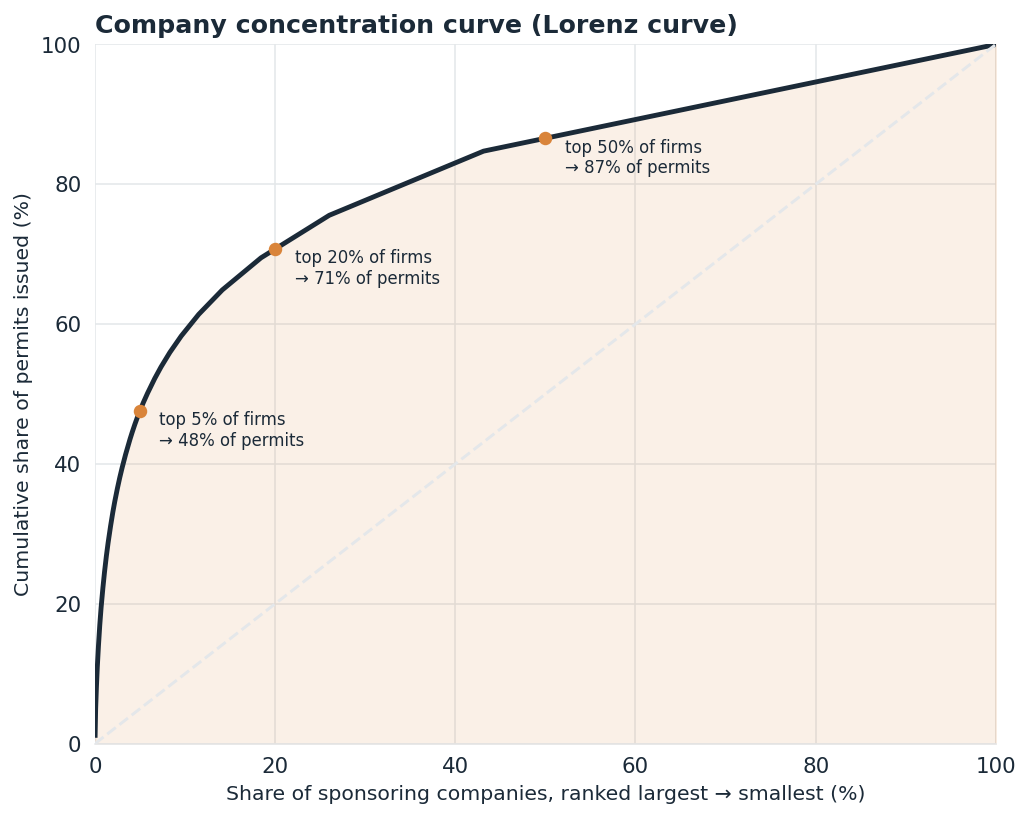

In [11]:

ranked = comp_wide.sort_values("total_issued", ascending=False).reset_index(drop=True)
cum_share = ranked["total_issued"].cumsum() / ranked["total_issued"].sum()
company_share = (ranked.index + 1) / len(ranked)

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.plot(company_share * 100, cum_share * 100, color=INK, linewidth=2.5)
ax.plot([0, 100], [0, 100], color=GRID, linewidth=1.5, linestyle="--")
ax.fill_between(company_share * 100, cum_share * 100, color=ACCENT, alpha=0.12)

for pct in [0.05, 0.20, 0.50]:
    idx = int(len(ranked) * pct) - 1
    ax.scatter([company_share[idx]*100], [cum_share[idx]*100], color=ACCENT, zorder=5, s=35)
    ax.annotate(f"top {pct:.0%} of firms\n→ {cum_share[idx]:.0%} of permits",
                (company_share[idx]*100, cum_share[idx]*100),
                textcoords="offset points", xytext=(10, -18), fontsize=8.5, color=INK)

ax.set_title("Company concentration curve (Lorenz curve)")
ax.set_xlabel("Share of sponsoring companies, ranked largest → smallest (%)")
ax.set_ylabel("Cumulative share of permits issued (%)")
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()



Two things are true at once here, and the curve captures both.

**No single employer dominates.** Google Ireland, the top sponsor, accounts
for only ~1.2% of the national total, and the top 20 companies combined —
literally 0.2% of all sponsors — are just 10.6% of permits. This is not a
story of one or two firms driving the scheme.

**But sponsorship is still meaningfully concentrated overall.** The busiest
**5% of companies (~416 firms) account for roughly 48% of all permits**, and
the busiest **20% (~1,670 firms) account for 71%** — well above the
diagonal "everyone sponsors equally" line. At the other end, **4,742
companies — 57% of all sponsors — issued exactly one permit all year.**

Put together: there's a long tail of thousands of employers each sponsoring
a single hire (a restaurant, a clinic, a single family employing a carer),
sitting alongside a mid-sized core of a few hundred larger, repeat
sponsors — hospital groups, tech multinationals, care-home operators,
consultancies — that collectively account for most of the volume. It's
concentrated, but not monopolised.



## 7. Key findings

- **India dominates nationality of origin**, accounting for roughly a third
  of all permits issued in 2025 — more than the next five countries combined.
- **Refusal rates are broadly consistent (~4–19%)** across higher-volume
  nationalities once low-sample noise is filtered out; no nationality is a
  dramatic outlier relative to the 10.0% national average.
- **Dublin absorbs nearly half of all permits nationally**, reflecting its
  concentration of healthcare, tech and multinational employers; Cork,
  Limerick, Meath and Kildare form a distant second tier.
- **Health & Social Work Activities is the single largest sector**, at
  roughly a quarter of all permits — well ahead of tech (Information &
  Communication) and Accommodation & Food Services.
- **Sponsorship is a long tail with a concentrated core.** No single company
  dominates (the top sponsor is ~1% of the total), but the busiest 20% of
  ~8,300 sponsoring companies still account for 71% of permits, while 57% of
  companies sponsored just one permit all year — structural, economy-wide
  demand layered on top of a smaller core of large, repeat employers.

## Data & reproducibility

| File | Source |
|---|---|
| `data/raw/permits-by-nationality-2025.xlsx` | DETE Employment Permits Statistics 2025 |
| `data/raw/permits-by-county-2025.xlsx` | DETE Employment Permits Statistics 2025 |
| `data/raw/permits-by-sector-2025.xlsx` | DETE Employment Permits Statistics 2025 |
| `data/raw/permits-by-company-2025.xlsx` | DETE Employment Permits Statistics 2025 |

Run `python src/clean_data.py` to regenerate `data/processed/*.csv` from the
raw workbooks, then re-run this notebook (or `python src/build_notebook.py`
to rebuild it headlessly with fresh outputs baked in).
